In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos de estaciones en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Precipitaciones/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,1,VAEXJOE,SE,+56:52:00,+014:48:00,166
1,2,FALUN,SE,+60:37:00,+015:37:00,160
2,3,STENSELE,SE,+65:04:00,+017:09:59,325
3,4,LINKOEPING,SE,+58:24:00,+015:31:59,93
4,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
...,...,...,...,...,...,...
17116,27903,VALSTAGNA,IT,+45:51:45,+011:39:33,148
17117,27904,VICENZA - SANT'AGOSTINO,IT,+45:31:27,+011:31:13,29
17118,27939,TRONDHEIM - GRANASEN,NO,+63:22:32,+010:18:45,186
17119,27940,BARKALD,NO,+61:59:30,+010:53:11,452


In [3]:
#Filtrado de datos para Italia
metadata_IT=metadata[metadata.CN=='IT']
metadata_IT

,STAID,STANAME,CN,LAT,LON,HGHT
146,169,BOLOGNA,IT,+44:30:00,+011:20:45,53
147,170,FERRARA,IT,+44:49:57,+011:37:15,15
148,171,GENOA,IT,+44:24:52,+008:55:35,55
149,172,MANTOVA,IT,+45:09:29,+010:47:48,46
150,173,MILAN,IT,+45:28:18,+009:11:21,150
...,...,...,...,...,...,...
17113,27900,TURCATI (RECOARO TERME),IT,+45:42:14,+011:11:04,714
17114,27901,VALDAGNO,IT,+45:37:53,+011:18:30,229
17115,27902,VALLI DEL PASUBIO,IT,+45:45:28,+011:12:48,602
17116,27903,VALSTAGNA,IT,+45:51:45,+011:39:33,148


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_IT['LAT'] = metadata_IT['LAT'].apply(dms_a_decimal)
metadata_IT['LON'] = metadata_IT['LON'].apply(dms_a_decimal)
metadata_IT

,STAID,STANAME,CN,LAT,LON,HGHT
146,169,BOLOGNA,IT,44.500000,11.345833,53
147,170,FERRARA,IT,44.832500,11.620833,15
148,171,GENOA,IT,44.414444,8.926389,55
149,172,MANTOVA,IT,45.158056,10.796667,46
150,173,MILAN,IT,45.471667,9.189167,150
...,...,...,...,...,...,...
17113,27900,TURCATI (RECOARO TERME),IT,45.703889,11.184444,714
17114,27901,VALDAGNO,IT,45.631389,11.308333,229
17115,27902,VALLI DEL PASUBIO,IT,45.757778,11.213333,602
17116,27903,VALSTAGNA,IT,45.862500,11.659167,148


In [6]:
#Carga de mapas para obtener mapa de Italia
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
italia = world[world["name"] == "Italy"] #Mapa de Italia

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_IT['LON'], metadata_IT['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_IT, geometry=estaciones, crs="EPSG:4326") 

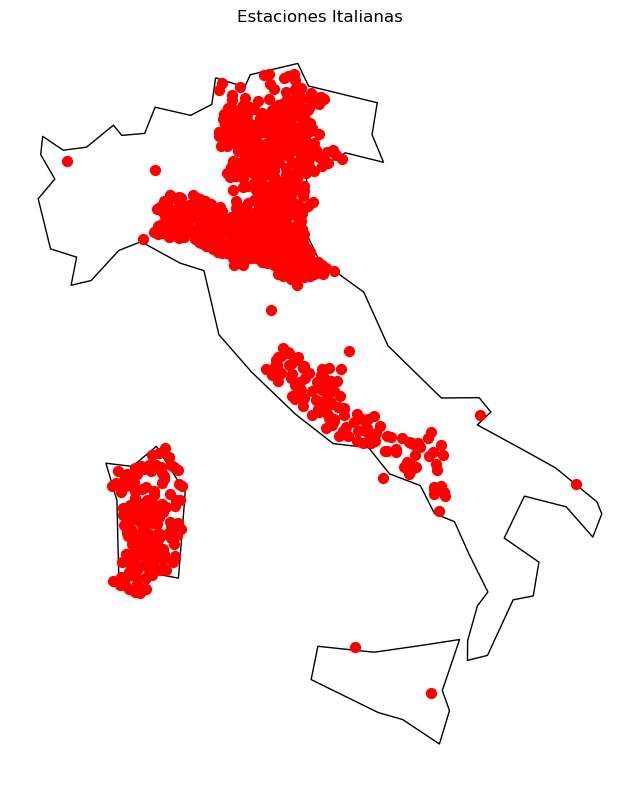

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones italianas
lista_estaciones_italianas=metadata_IT.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='RR_STAID000000'
station_i=station[:-len(str(lista_estaciones_italianas[0]))]+str(lista_estaciones_italianas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Precipitaciones/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9) & (data.DATE<'2025-01-01')]
data_unif=data.loc[:,['DATE','RR']]
data_unif.set_index('DATE', inplace=True)
data_unif

,RR
DATE,
2008-01-01,0
2008-01-02,0
2008-01-03,16
2008-01-04,30
2008-01-05,20
...,...
2024-12-27,0
2024-12-28,0
2024-12-29,0


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_italianas[1:]:
    station='RR_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Precipitaciones/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
    df=data.loc[:,['DATE','RR']]
    df.set_index('DATE', inplace=True)
    data_unif['RR '+str(i)]=df

data_unif

,RR,RR 170,RR 171,RR 172,RR 173,RR 174,RR 176,RR 177,RR 380,RR 381,...,RR 27895,RR 27896,RR 27897,RR 27898,RR 27899,RR 27900,RR 27901,RR 27902,RR 27903,RR 27904
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,0,0.0,0.0,2.0,0.0,104.0,0.0,0.0,0.0,32.0,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
2008-01-02,0,0.0,6.0,0.0,0.0,34.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
2008-01-03,16,30.0,36.0,2.0,0.0,4.0,2.0,11.0,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
2008-01-04,30,70.0,198.0,0.0,22.0,6.0,1.0,32.0,38.0,0.0,...,NaN,NaN,NaN,NaN,NaN,51,NaN,NaN,NaN,NaN
2008-01-05,20,30.0,70.0,0.0,222.0,10.0,303.0,42.0,88.0,0.0,...,NaN,NaN,NaN,NaN,NaN,277,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,2.0
2024-12-28,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
2024-12-29,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,2.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen mas de un 2% de datos faltantes y se renombra la primera estación 
# con el ID de estación
d=data_unif.dropna(thresh=round(data_unif.shape[0]*0.98), axis=1)
d=d.rename({'RR':'RR '+str(lista_estaciones_italianas[0])},axis=1)
d

,RR 169,RR 170,RR 1735,RR 1736,RR 2766,RR 2777,RR 2785,RR 2797,RR 2827,RR 2839,...,RR 26270,RR 26275,RR 26278,RR 26292,RR 27743,RR 27784,RR 27785,RR 27786,RR 27796,RR 27900
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,2.0,4,2.0,2,0
2008-01-02,0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,10.0,NaN,0.0,0.0,2.0,0,0.0,0,0
2008-01-03,16,30.0,0.0,0.0,2.0,54.0,2.0,0.0,2.0,10.0,...,34.0,38.0,4.0,34.0,8.0,54.0,6,10.0,10,0
2008-01-04,30,70.0,8.0,6.0,98.0,46.0,98.0,14.0,14.0,56.0,...,35.0,24.0,4.0,35.0,12.0,46.0,36,56.0,56,51
2008-01-05,20,30.0,8.0,4.0,26.0,18.0,26.0,8.0,4.0,30.0,...,163.0,53.0,60.0,163.0,42.0,18.0,8,30.0,30,277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,NaN,0.0,0.0,2,0.0,2,0
2024-12-28,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,NaN,0.0,0.0,0,0.0,0,0
2024-12-29,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,NaN,0.0,0.0,0,0.0,0,0


In [13]:
# Estaciones italianas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_IT[metadata_IT.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
146,169,BOLOGNA,IT,44.500000,11.345833,53
147,170,FERRARA,IT,44.832500,11.620833,15
1273,1735,CERVIA,IT,44.272500,12.318889,2
1274,1736,RIMINI,IT,44.058333,12.579444,7
2110,2766,ANZOLA DELL EMILIA,IT,44.579167,11.182500,42
...,...,...,...,...,...,...
16998,27784,ADRIA - BELLOMBRA,IT,45.015556,12.007778,-1
16999,27785,BAGNOLO DI PO - PELLIZZARE,IT,44.989167,11.529167,6
17000,27786,CASTELNOVO BARIANO,IT,45.030833,11.302500,10
17010,27796,TRECENTA,IT,45.021667,11.426667,9


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

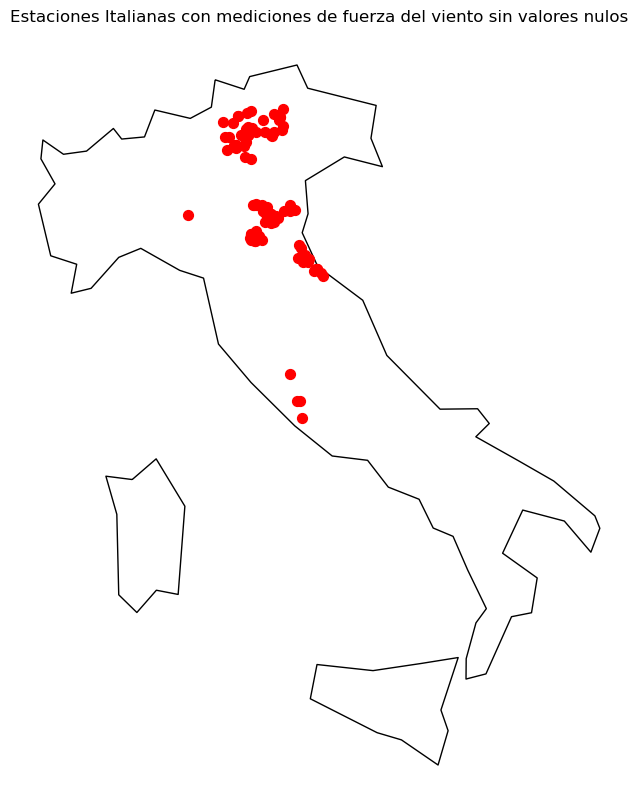

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_it=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_it['LON'],mt_it['LAT'],mt_it['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_IT=mt_it[mt_it.STAID.isin(ww)]
mt_IT

,STAID,STANAME,CN,LAT,LON,HGHT
146,169,BOLOGNA,IT,44.500000,11.345833,53
1273,1735,CERVIA,IT,44.272500,12.318889,2
2164,2839,MOGLIA DI SERMIDE,IT,45.013056,11.255833,12
2220,2945,VIGNA DI VALLE,IT,42.082778,12.216667,266
6670,10915,ARCO,IT,45.920000,10.885000,100
11754,17576,CASTELLARQUATO,IT,44.868889,9.875000,155
13681,21784,CONCA,IT,43.958056,12.700000,19
16998,27784,ADRIA - BELLOMBRA,IT,45.015556,12.007778,-1


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_IT['LON'], mt_IT['LAT'])] 
puntos = gpd.GeoDataFrame(mt_IT, geometry=estaciones, crs="EPSG:4326") 

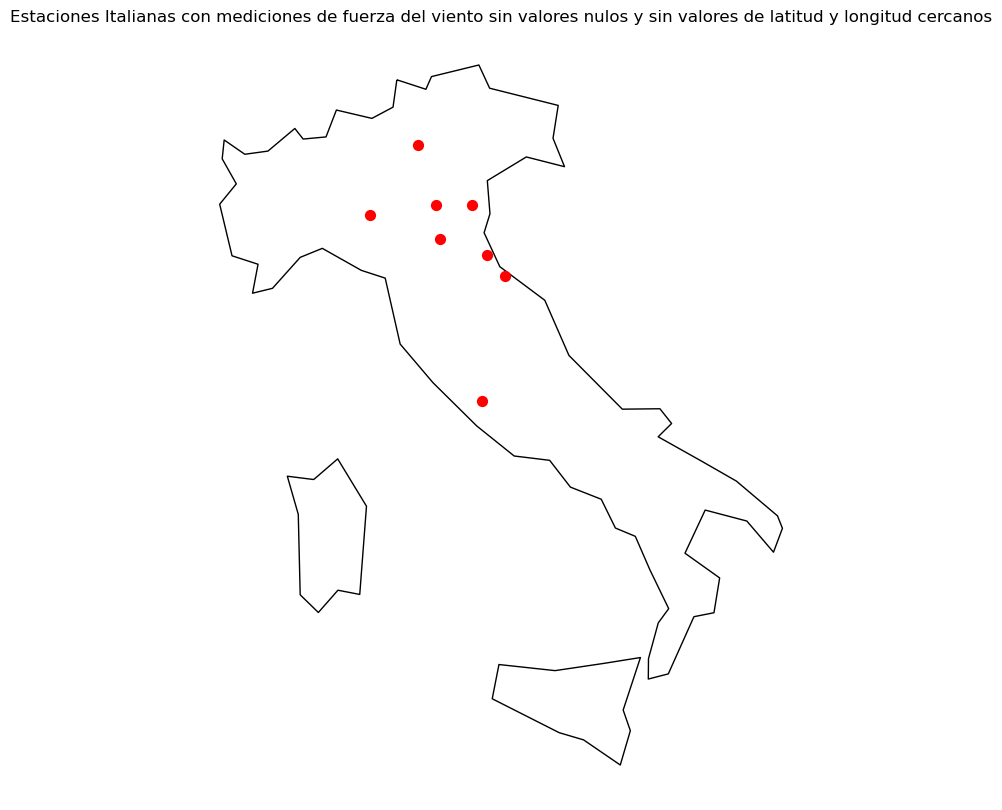

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['RR '+str(i) for i in mt_IT.STAID.to_list()]]
data=data.resample('MS').mean()
data

,RR 169,RR 1735,RR 2839,RR 2945,RR 10915,RR 17576,RR 21784,RR 27784
DATE,,,,,,,,
2008-01-01,12.516129,10.000000,13.935484,32.774194,28.709677,23.354839,8.193548,14.000000
2008-02-01,4.344828,7.586207,5.103448,13.517241,12.896552,6.896552,5.241379,7.034483
2008-03-01,14.774194,33.032258,10.580645,50.645161,24.307692,9.419355,51.290323,12.838710
2008-04-01,4.133333,12.866667,19.000000,20.466667,78.000000,32.466667,23.466667,16.200000
2008-05-01,51.870968,21.483871,37.419355,37.354839,39.870968,45.225806,19.741935,11.870968
...,...,...,...,...,...,...,...,...
2024-08-01,25.935484,25.870968,12.193548,4.967742,16.322581,8.129032,8.903226,25.935484
2024-09-01,64.333333,75.066667,21.428571,25.851852,64.400000,44.133333,93.600000,41.200000
2024-10-01,105.741935,32.967742,59.483871,41.793103,75.096774,120.516129,55.806452,57.483871


In [21]:
#Cálculo de la media para cada mes en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'RR'},axis=1)
a

,RR
DATE,
2008-01-01,17.935484
2008-02-01,7.827586
2008-03-01,25.861042
2008-04-01,25.825000
2008-05-01,33.104839
...,...
2024-08-01,16.032258
2024-09-01,53.751720
2024-10-01,68.611235


In [24]:
#Exportación de datos mensuales de precipitaciones en Italia
a.to_csv('precipitaciones_mensuales_ita.csv',index=True,encoding='utf-8')

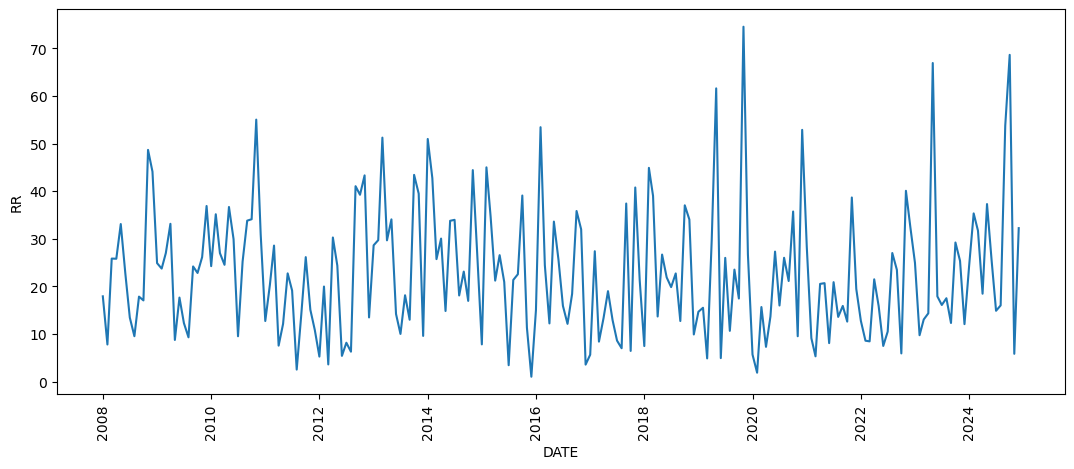

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.RR)
plt.xticks(rotation=90)
plt.show()